In [2]:
from ugot import ugot
got = ugot.UGOT()
got.initialize("192.168.1.10")

192.168.1.10:50051


# Color Picker
The following cell contains a helper script to find hue, saturation, and value (HSV) values using the UGOT camera.

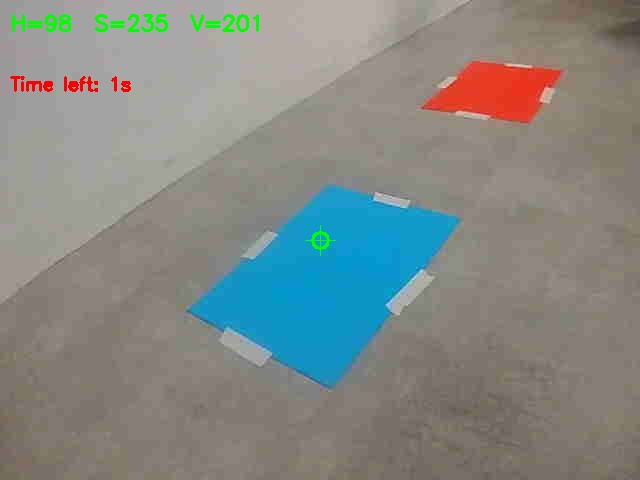

Finished 10-second live color picker.


In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

# 1. Open camera
got.open_camera()

# 2. Create a display window in Jupyter
dummy = np.zeros((240, 320, 3), np.uint8)
ok, jpg = cv2.imencode(".jpg", dummy)
handle = display(Image(data=jpg.tobytes()), display_id=True)

# 3. Show live video for 10 seconds
start_time = time.time()
duration = 10 # how many seconds before script ends

while time.time() - start_time < duration:
    picture_raw = got.read_camera_data()
    if picture_raw is None:
        continue

    # Convert raw bytes to BGR image
    picture_1D = np.frombuffer(picture_raw, np.uint8)
    picture_bgr = cv2.imdecode(picture_1D, cv2.IMREAD_COLOR)
    if picture_bgr is None:
        continue

    # Convert BGR to HSV
    picture_hsv = cv2.cvtColor(picture_bgr, cv2.COLOR_BGR2HSV)

    # Get image size
    height = picture_hsv.shape[0]
    width = picture_hsv.shape[1]

    # Find center point
    center_x = width // 2
    center_y = height // 2

    # Read HSV value at center pixel
    h = int(picture_hsv[center_y, center_x, 0])
    s = int(picture_hsv[center_y, center_x, 1])
    v = int(picture_hsv[center_y, center_x, 2])

    # Draw center marker
    cv2.circle(picture_bgr, (center_x, center_y), 8, (0, 255, 0), 2)
    cv2.line(picture_bgr, (center_x - 15, center_y), (center_x + 15, center_y), (0, 255, 0), 1)
    cv2.line(picture_bgr, (center_x, center_y - 15), (center_x, center_y + 15), (0, 255, 0), 1)

    # Show HSV value on screen
    text = f"H={h}  S={s}  V={v}"
    cv2.putText(picture_bgr, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Show countdown
    time_left = duration - int(time.time() - start_time)
    cv2.putText(picture_bgr, f"Time left: {time_left}s", (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # Encode and update display
    ok, jpg = cv2.imencode(".jpg", picture_bgr)
    if ok:
        handle.update(Image(data=jpg.tobytes()))

    time.sleep(0.05)

print("Finished live color picker.")

# Bounding box
How to draw a bounding box around recognised color withing a certain HSV range.

The camera is on.


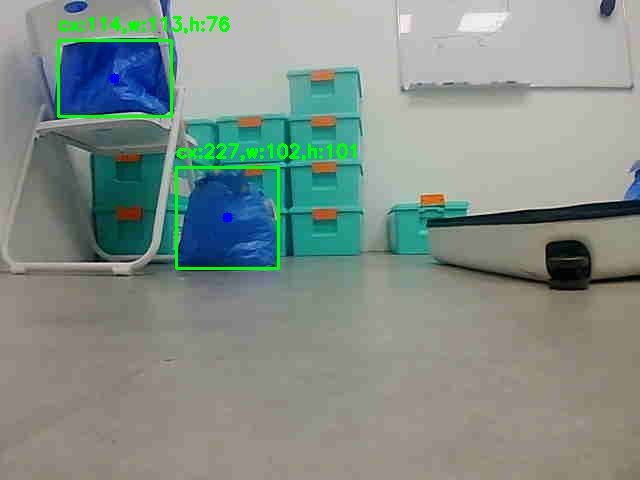

KeyboardInterrupt: 

In [ ]:
import time
import numpy as np
import cv2
from IPython.display import display, Image

# open camera
got.open_camera()
print("The camera is on.")
picture_raw = got.read_camera_data()
if picture_raw is None:
    raise Exception("No camera data.")

# raw data to 1D array
picture_1D = np.frombuffer(picture_raw,np.uint8)
picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
if picture_bgr is None:
    raise Exception("Check the camera.")

# Use handle for live updates in Jupyter
ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
handle = display(Image(picture_jpg.tobytes()),display_id = True)

# Detect the color
lower_color = np.array([100,200,90])
upper_color = np.array([200,255,255])

# take video
start_time = time.time()
duration = 10

while time.time() - start_time < duration:
    picture_raw = got.read_camera_data()
    if picture_raw is None:
        continue

    picture_1D = np.frombuffer(picture_raw,np.uint8)
    picture_bgr = cv2.imdecode(picture_1D,cv2.IMREAD_COLOR)  
    if picture_bgr is None:
        continue
    picture_hsv = cv2.cvtColor(picture_bgr,cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(picture_hsv,lower_color,upper_color)
    # find contours
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        area = cv2.contourArea(contour)
        if area>1000:
            x,y,w,h = cv2.boundingRect(contour)
            # center of the bounding box
            center_x = x + w//2
            # draw a bounding box
            cv2.rectangle(picture_bgr,(x,y),(x+w,y+h),(0,255,0),2)
            # draw center point
            cv2.circle(picture_bgr,(center_x,y+h//2),5,(255,0,0),-1)
            # show text x,y,w,h and center
            text = f"cx:{center_x},w:{w},h:{h}"
            # keep text visible
            text_y = max(30,y-10)
            # draw text
            cv2.putText(picture_bgr,text,(x,text_y),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
    # update live video
    ok,picture_jpg = cv2.imencode(".jpg",picture_bgr)
    if ok:
        handle.update(Image(picture_jpg.tobytes()))

    time.sleep(0.1)